### Mercury Calibration

This code loads our recorded Hg spectrum and determines the wavelength offset of the monochromator.

We manually specify six approximate peak positions (based on the plotted spectrum).  
For each guess, the code looks ±3 nm around it and simply takes the **maximum intensity** in that region.  
This gives the exact measured wavelength of each Hg emission line.

We then compare these measured peak positions to the literature values and compute the individual shifts  
Δλᵢ = λ_ref − λ_meas.  
Their mean gives the global wavelength correction, which we apply to all spectra using `apply_calibration()`.

In [ ]:
import numpy as np

# --- Known Hg reference wavelengths (nm) ---
hg_ref = np.array([365.0, 404.7, 435.8, 546.1, 577.0, 579.0])

# --- Approximate peak positions seen by eye in the spectrum ---
initial_guesses = np.array([369, 409, 440, 551, 583, 585])

# --- The only file this calibration will use ---
hg_filename = "15Uhr03_FP_Ba11_Hg_Spectrum_50mV.dat"


def load_hg_spectrum():
    """Load the fixed mercury calibration file and return (wavelength, intensity)."""
    with open(hg_filename, "r", encoding="utf-8") as f:
        start = float(f.readline().replace(",", "."))
        gear  = float(f.readline().replace(",", "."))
        direction = float(f.readline().replace(",", "."))

        data = np.loadtxt((line.replace(",", ".") for line in f))

    t = data[:, 0]
    I_raw = data[:, 1]

    # Wavelength axis
    wl = start + direction * gear * t

    # Flip sign so peaks go upward
    I = -I_raw

    # Ensure ascending wavelength order
    if wl[0] > wl[-1]:
        wl = wl[::-1]
        I  = I[::-1]

    return wl, I


def refine_peak(wl, I, guess, window=3):
    """Refine peak position by taking the maximum within ±window nm of a guessed location."""
    mask = (wl >= guess - window) & (wl <= guess + window)
    wl_win = wl[mask]
    I_win  = I[mask]

    idx = np.argmax(I_win)
    return wl_win[idx]


def perform_hg_calibration():
    """
    Finds the exact measured Hg peak wavelengths and computes the wavelength offset Δλ.
    """
    wl, I = load_hg_spectrum()

    # refine all 6 peaks
    measured = np.array([refine_peak(wl, I, g) for g in initial_guesses])

    # compute shifts
    shifts = hg_ref - measured
    shift_mean = shifts.mean()

    print("Reference Hg lines (nm):", hg_ref)
    print("Measured Hg peaks (nm): ", measured)
    print("Individual shifts (nm):", shifts)
    print(f"\nMean wavelength shift Δλ = {shift_mean:.3f} nm")

    return shift_mean, measured, wl, I


# --- Run calibration immediately ---
shift, measured_peaks, wl_hg, I_hg = perform_hg_calibration()


def apply_calibration(wavelength, shift=shift):
    """Apply Δλ shift to any wavelength axis."""
    return np.asarray(wavelength) + shift


Reference Hg lines (nm): [365.  404.7 435.8 546.1 577.  579. ]
Measured Hg peaks (nm):  [369.3 409.  440.4 550.8 581.7 583.8]
Individual shifts (nm): [-4.3 -4.3 -4.6 -4.7 -4.7 -4.8]

Mean wavelength shift Δλ = -4.567 nm


---

### ***Measured Hg Spectrum Plot***

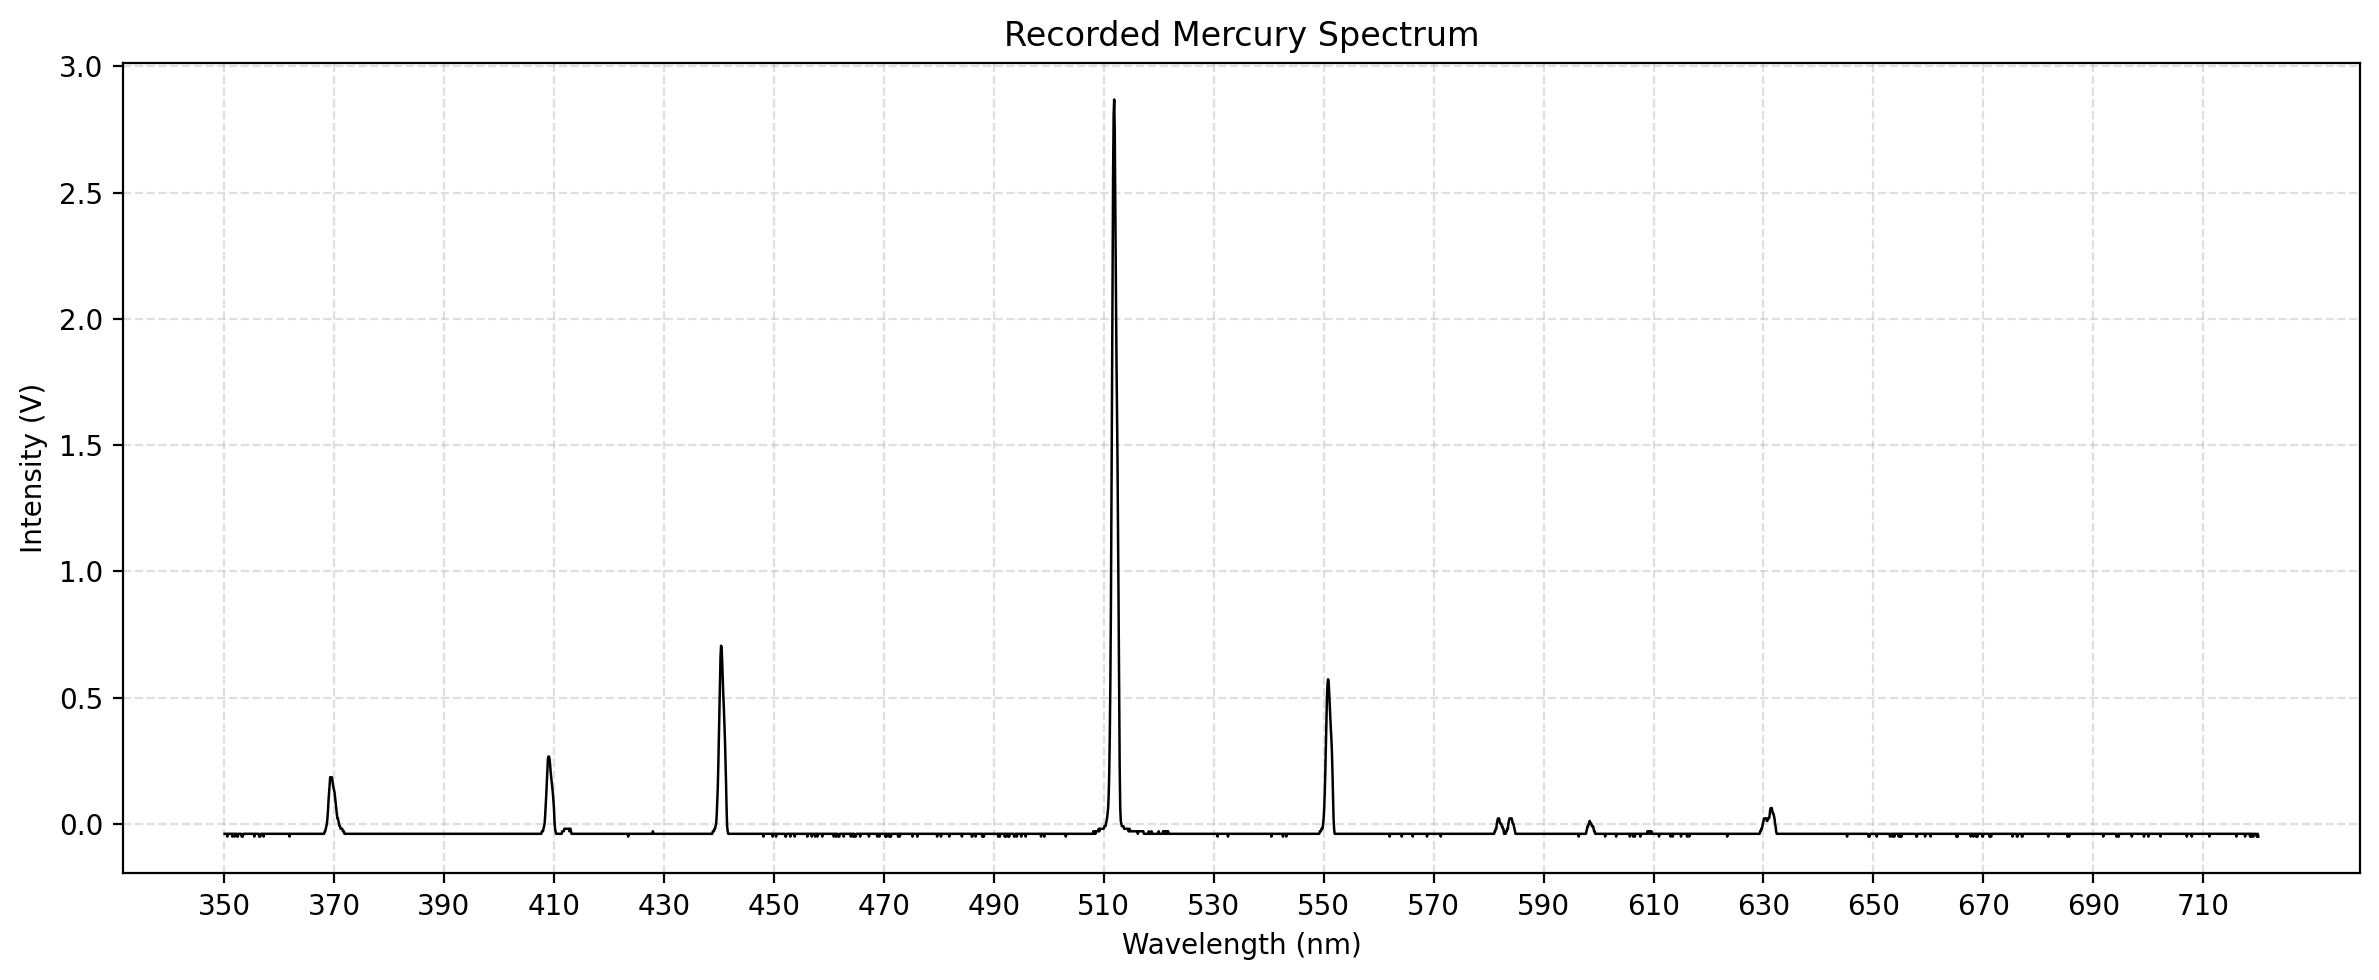

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fname = "15Uhr03_FP_Ba11_Hg_Spectrum_50mV.dat"

# ----------- read file -----------
with open(fname, "r", encoding="utf-8") as f:
    lines = f.readlines()

# ----------- metadata -----------
start_wavelength = float(lines[0].strip().replace(",", "."))  # e.g. 720 nm
gear_factor      = float(lines[1].strip().replace(",", "."))  # = nm/s
direction        = int(lines[2].strip())                      # +1 or -1

# ----------- data -----------
data = []
for line in lines[3:]:
    line = line.strip()
    if not line:
        continue
    line = line.replace(",", ".")
    parts = line.split()
    if len(parts) == 2:
        t, I = map(float, parts)
        data.append([t, I])

data = np.array(data)
t = data[:, 0]
I = -data[:, 1]           # flip sign so peaks point upward

# ----------- wavelength axis -----------
nm_per_s = gear_factor    # ***correct: directly nm/s***

if direction == 1:
    wl_raw = start_wavelength + nm_per_s * t
else:
    wl_raw = start_wavelength - nm_per_s * t

# we want wavelength increasing left → right
if wl_raw[0] > wl_raw[-1]:
    wavelength = wl_raw[::-1]
    intensity  = I[::-1]
else:
    wavelength = wl_raw
    intensity  = I

# ----------- plot -----------
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(wavelength, intensity, linewidth=0.9, color="black")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (V)")
plt.title("Recorded Mercury Spectrum")

xmin = np.floor(wavelength.min() / 25) * 25
xmax = np.ceil(wavelength.max() / 25) * 25
plt.xticks(np.arange(xmin, xmax + 1, 20))

plt.grid(alpha=0.4, linestyle="--")
plt.tight_layout()
plt.show()
